DSCI 552 Homework 1
===================

- Name: [Atharva Vilas Wagh]
- GitHub Username: [awagh29]
- USD ID: 5942-4066-12

In [1]:
!pip freeze > requirements.txt 

In [ ]:
!pip install -r requirements.txt

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.io import arff
import os
from collections import Counter
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import math
from decimal import Decimal
from sklearn.neighbors import KNeighborsClassifier

### Q1. (a)

In [4]:
DATA_DIR = '../data/'

In [5]:
data = []
if os.path.isdir(DATA_DIR):
    print("Fetching data files")
    for filename in os.listdir(DATA_DIR):
        print(f"Looking for {filename}")
        fullpath = os.path.join(DATA_DIR, filename)
        if os.path.join(DATA_DIR, filename) and filename.endswith('.arff'):
            print(f"Data file {filename} path: {fullpath}")
            data.append(fullpath)

Fetching data files
Looking for .ipynb_checkpoints
Looking for column_2C.dat
Looking for column_2C_weka.arff
Data file column_2C_weka.arff path: ../data/column_2C_weka.arff
Looking for column_3C.dat
Looking for column_3C_weka.arff
Data file column_3C_weka.arff path: ../data/column_3C_weka.arff
Looking for important_data.csv


In [6]:
data

['../data/column_2C_weka.arff', '../data/column_3C_weka.arff']

In [7]:
raw_data = arff.loadarff(str(data[0]))
df = pd.DataFrame(raw_data[0])
df.head(3)

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,b'Abnormal'
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,b'Abnormal'
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,b'Abnormal'


In [8]:
variables = df.columns.tolist()
variables

['pelvic_incidence',
 'pelvic_tilt',
 'lumbar_lordosis_angle',
 'sacral_slope',
 'pelvic_radius',
 'degree_spondylolisthesis',
 'class']

### Q1. (b) i)

In [9]:
independent_vars = []
for i in range(len(variables) - 1):
  independent_vars.append(variables[i])
print(independent_vars)

['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis']


In [10]:
dependent_var = str(variables[len(variables) - 1])
df[dependent_var] = df[dependent_var].str.decode('utf-8')
print(f"dependent varibale is: {dependent_var}")

dependent varibale is: class


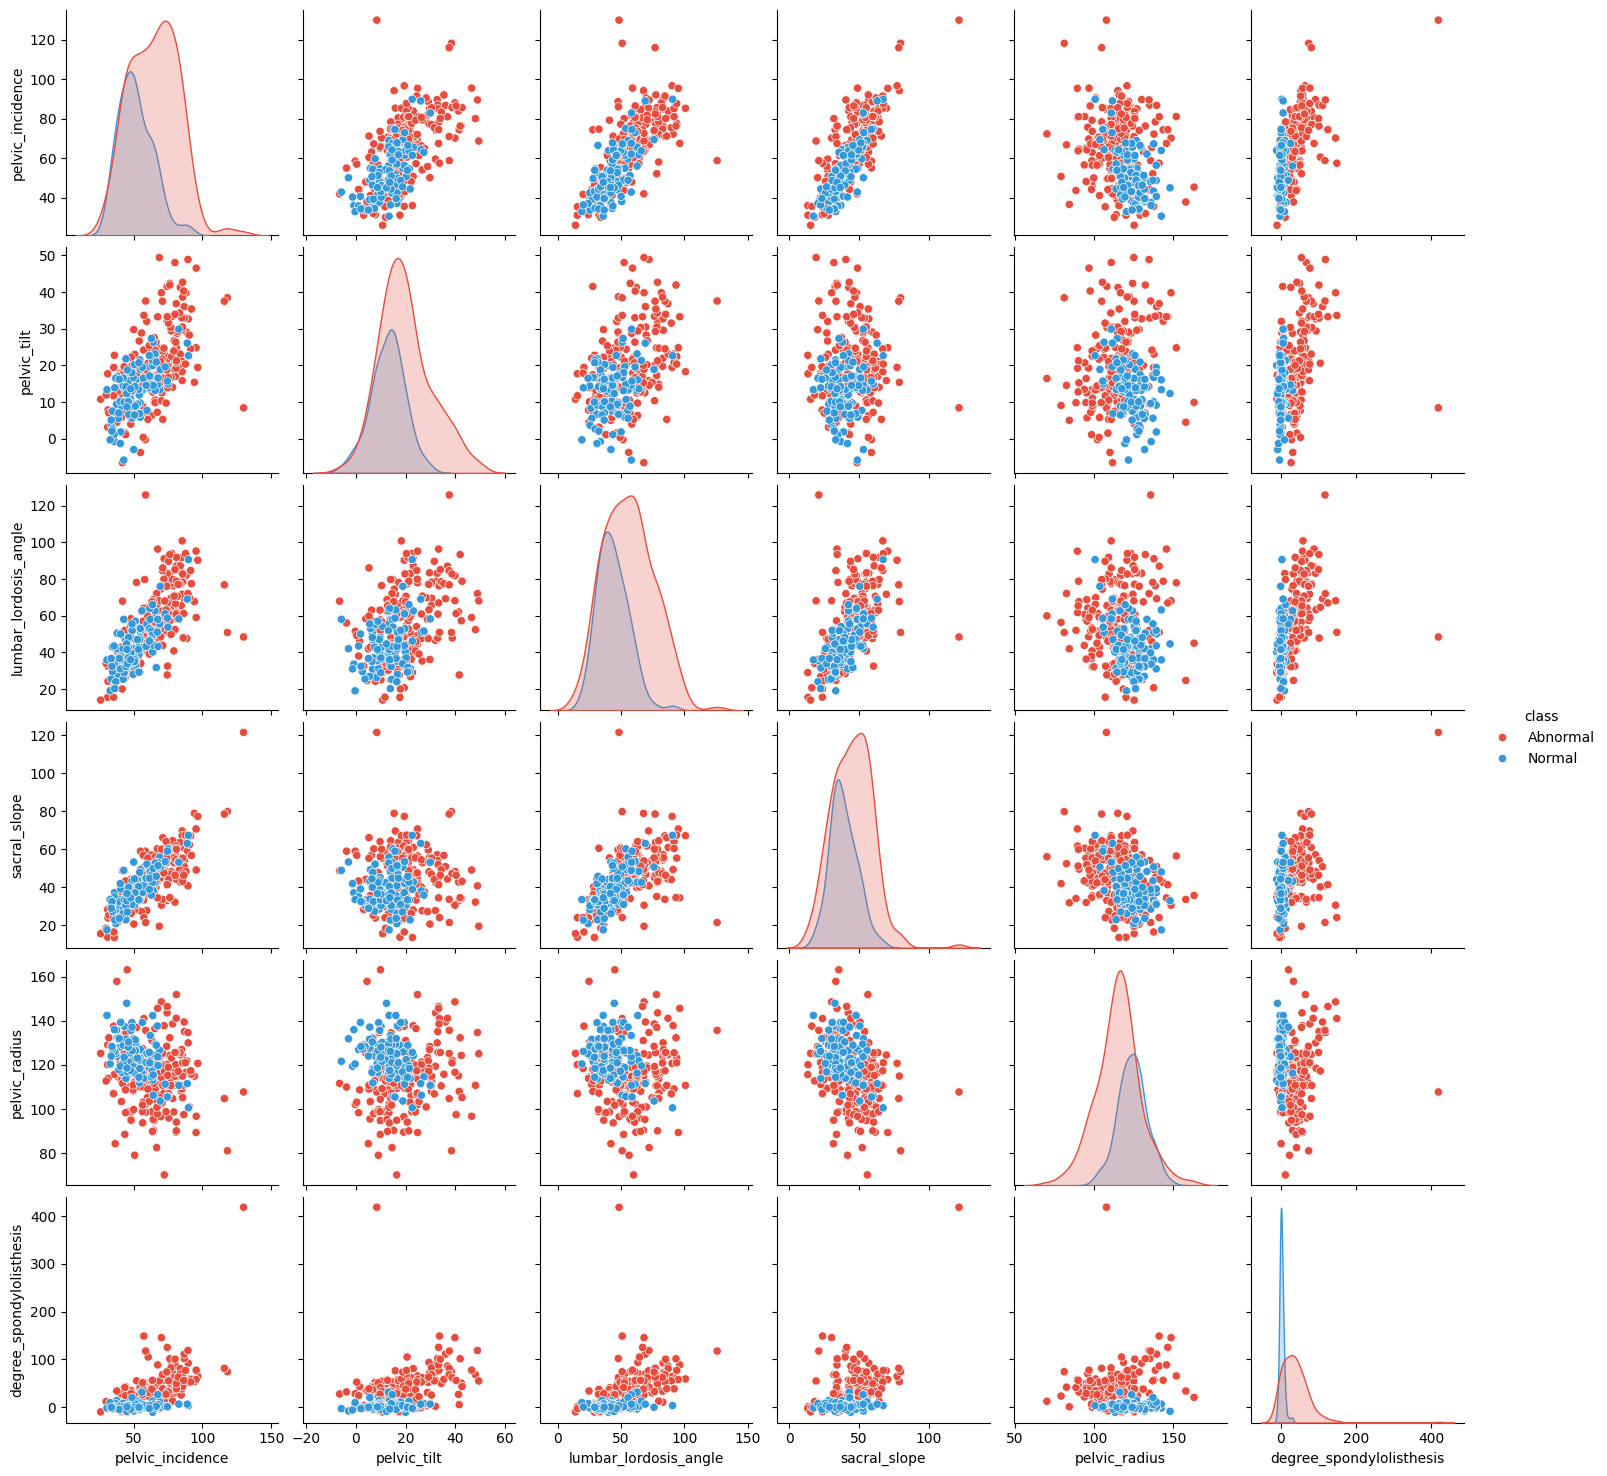

In [11]:
custom = {"Abnormal": "#E74C3C", "Normal": "#3498DB"}
sns.pairplot(df, hue=dependent_var, palette=custom, diag_kind='kde')
plt.show()

### Q1. (b) ii)

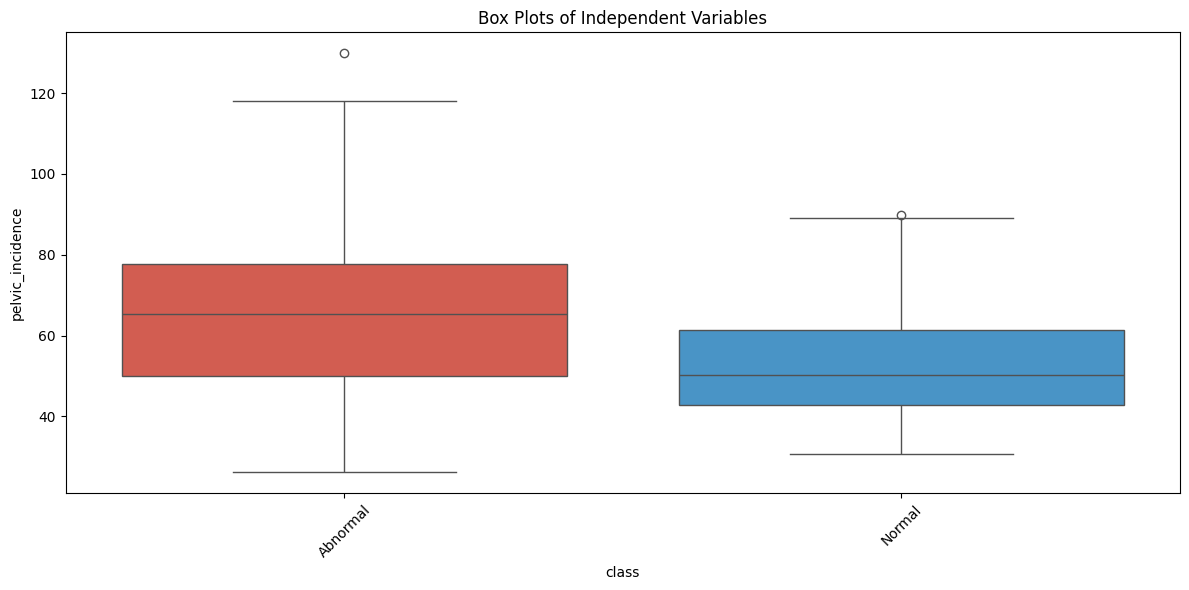

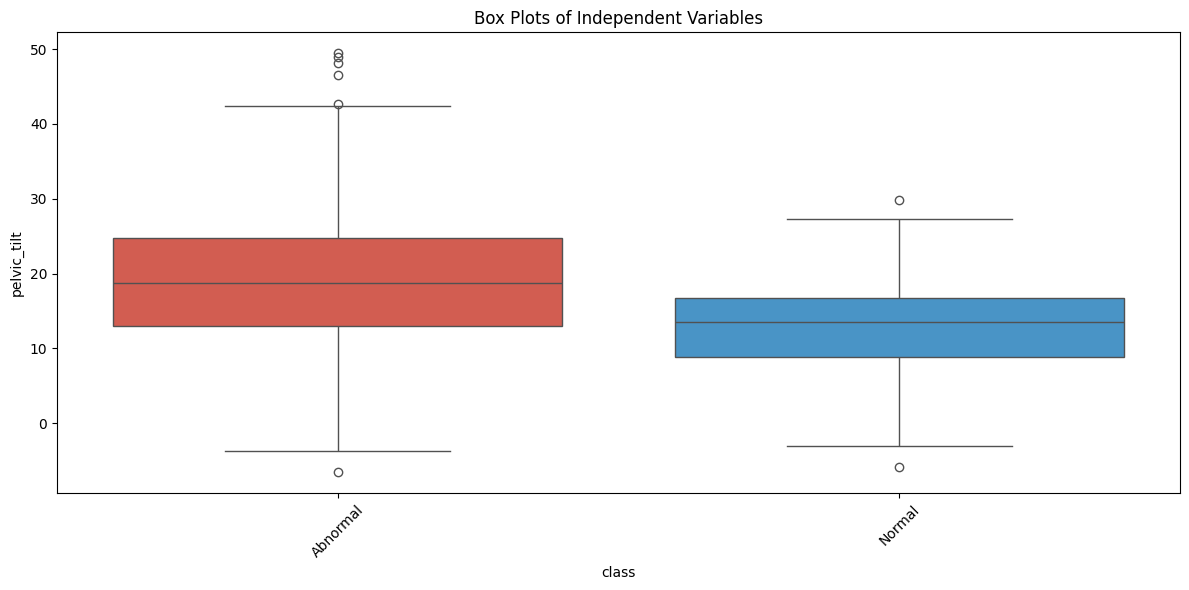

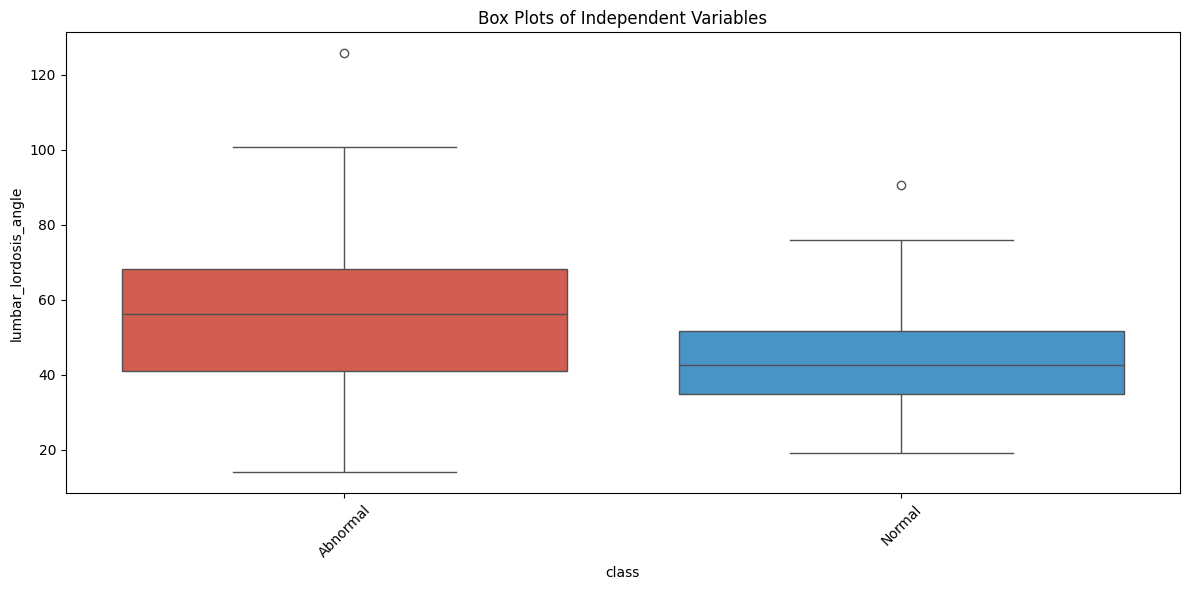

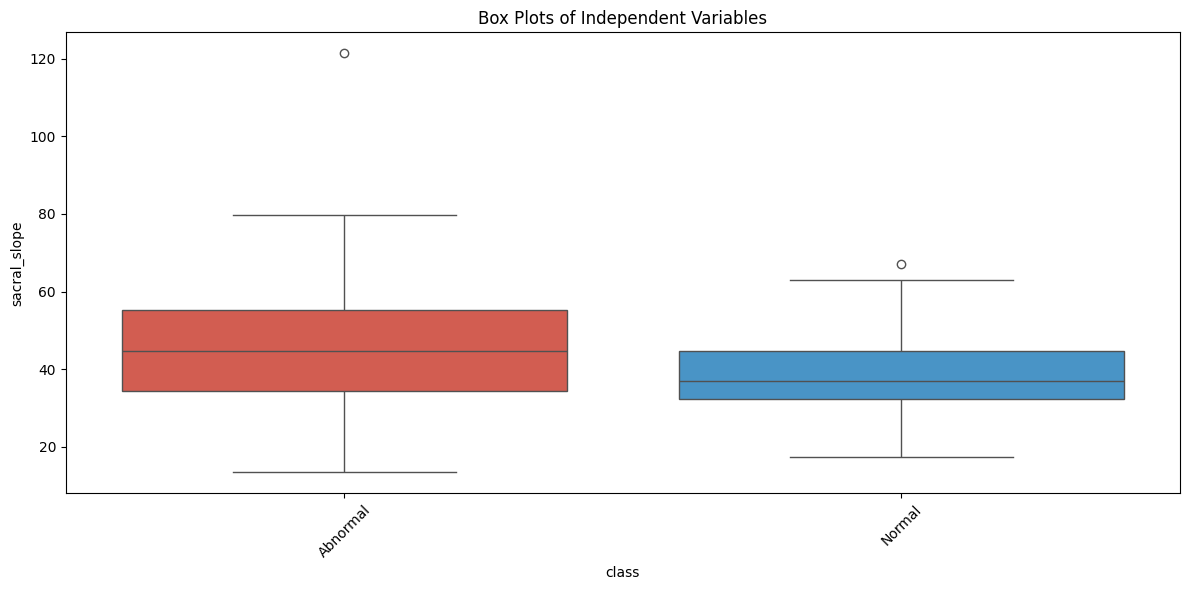

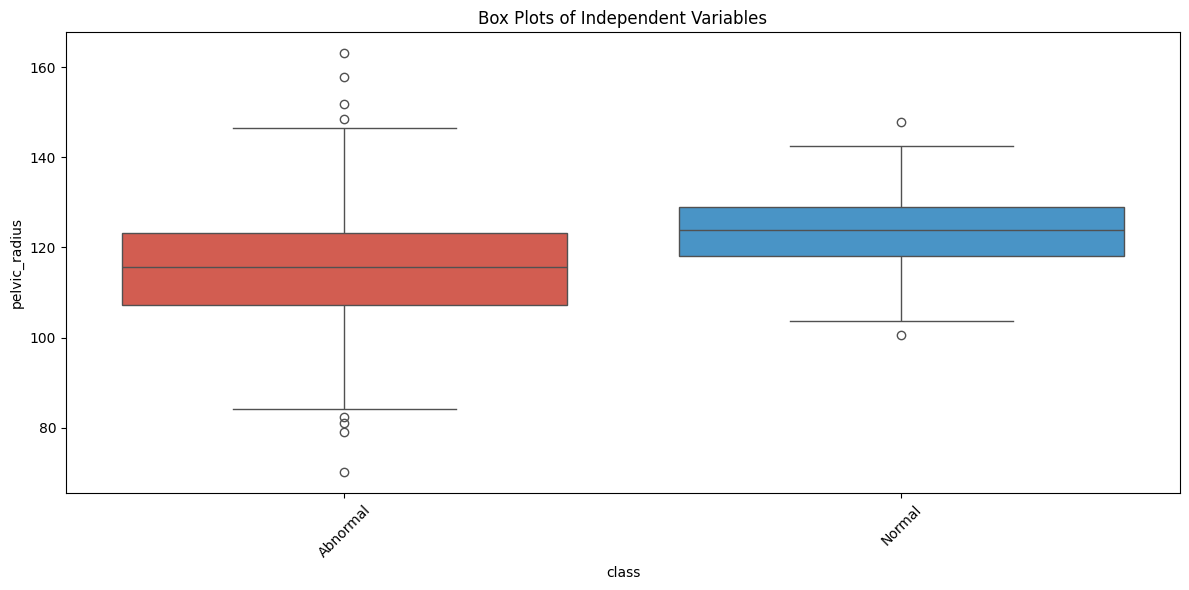

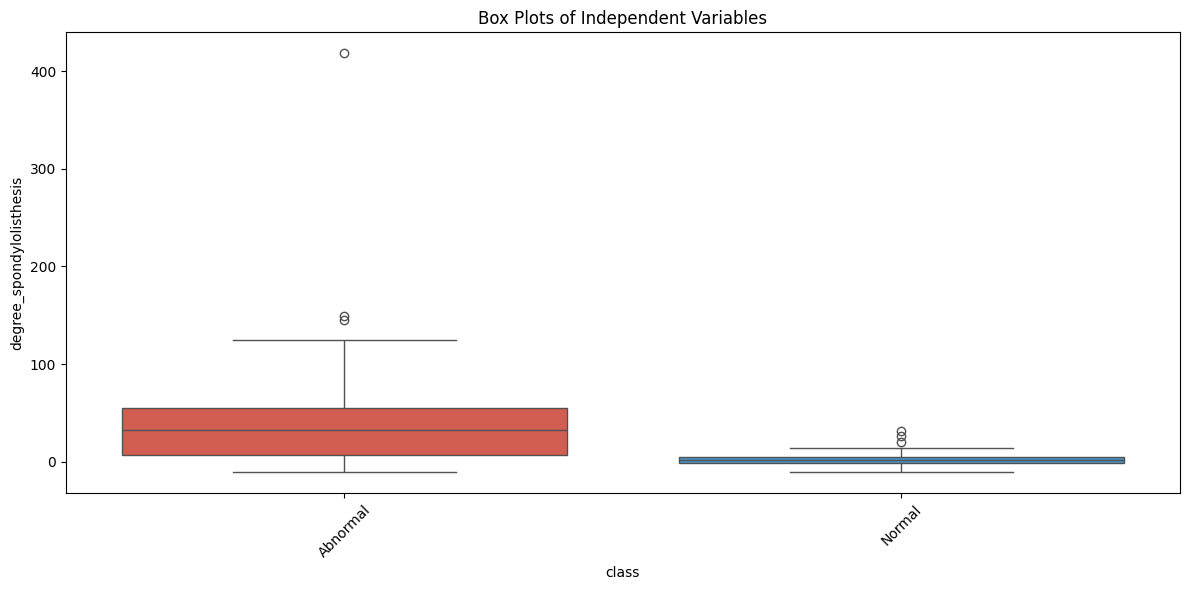

In [12]:
for i in independent_vars:
  plt.figure(figsize=(12, 6))
  sns.boxplot(x=str(dependent_var), y=str(i), data=df, palette=custom, hue=dependent_var, legend=False)
  plt.xticks(rotation=45)
  plt.title('Box Plots of Independent Variables')
  plt.tight_layout()
  plt.show()

### Q1. (b) iii)

In [13]:
print(df['class'].value_counts())

class
Abnormal    210
Normal      100
Name: count, dtype: int64


In [14]:
df_train = pd.concat([df.loc[df['class'] == 'Normal'].head(70), df.loc[df['class'] == 'Abnormal'].head(140)])
df_train['class'].value_counts()

class
Abnormal    140
Normal       70
Name: count, dtype: int64

In [15]:
test = df.loc[df['class'] == 'Normal'].iloc[70:]
test2 = df.loc[df['class'] == 'Abnormal'].iloc[140:]
df_test = pd.concat([test, test2])
df_test['class'].value_counts()

class
Abnormal    70
Normal      30
Name: count, dtype: int64

In [16]:
len(df_train)

210

In [17]:
df_train['class'] = df_train['class'].map({'Normal': 0, 'Abnormal': 1})
df_train['class'].value_counts()

class
1    140
0     70
Name: count, dtype: int64

In [18]:
df_test['class'] = df_test['class'].map({'Normal': 0, 'Abnormal': 1})
df_test['class'].value_counts()

class
1    70
0    30
Name: count, dtype: int64

### Q1. (c) i)

In [19]:
# Function for euclidean distance
def euclidean_dist(x1, x2):
    dist = np.sqrt(np.sum((x1 - x2)**2))
    return dist

In [20]:
# Custom KNN class
class KNN:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        dists = [euclidean_dist(x, x_train) for x_train in self.X_train]

        k_indices = np.argsort(dists)[:self.k]
        k_n_labels = [self.y_train[i] for i in k_indices]

        most_comm = Counter(k_n_labels).most_common()
        return most_comm[0][0]

In [21]:
df_train.head(3)

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
210,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,0
211,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,0
212,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,0


In [22]:
X_train = df_train.drop(columns='class').to_numpy(dtype=float)
X_train

array([[ 38.50527283,  16.96429691,  35.11281407,  21.54097592,
        127.6328747 ,   7.98668323],
       [ 54.92085752,  18.96842952,  51.60145541,  35.952428  ,
        125.8466462 ,   2.00164247],
       [ 44.36249017,   8.94543489,  46.90209626,  35.41705528,
        129.220682  ,   4.99419529],
       ...,
       [ 83.39660609,  34.31098931,  78.42329287,  49.08561678,
        110.4665164 ,  49.67209559],
       [ 72.05403412,  24.70073725,  79.87401586,  47.35329687,
        107.1723576 ,  56.42615873],
       [ 85.09550254,  21.06989651,  91.73479193,  64.02560604,
        109.062312  ,  38.03283108]], shape=(210, 6))

In [ ]:
X_test  = df_test.drop(columns='class').to_numpy(dtype=float)
X_test

In [24]:
y_train = df_train['class'].values
y_train

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [25]:
y_test = df_test['class'].values
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [26]:
model = KNN(k=5)
model.fit(X_train, y_train)

In [27]:
preds = model.predict(X_test)

In [28]:
print("Normal ", preds.count(0), "Abnormal", preds.count(1), "Length of preds: ", len(preds))

Normal  20 Abnormal 80 Length of preds:  100


In [29]:
cnf_mtr = confusion_matrix(y_test, preds)
print(cnf_mtr)

[[20 10]
 [ 0 70]]


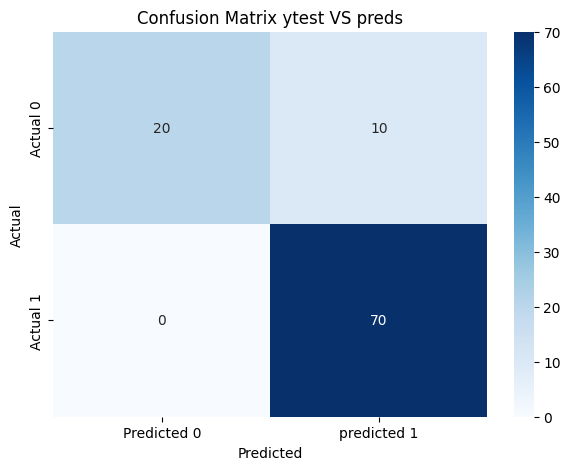

In [30]:
df_cm = pd.DataFrame(cnf_mtr, index=['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'predicted 1'])

plt.figure(figsize=(7, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix ytest VS preds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# This is for k = 5

In [31]:
# True Positive Rate, True -ve Rate, precision, and F1-score for k = 5
tn, fp, fn, tp = cnf_mtr.ravel()
accu = accuracy_score(y_test, preds)
pr_ = precision_score(y_test, preds)
recall_ = recall_score(y_test, preds)
f1_ = f1_score(y_test, preds)
print(f"Accuracy: {accu}, Precision: {pr_}, Recall: {recall_}, F1_Score: {f1_}")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

Accuracy: 0.9, Precision: 0.875, Recall: 1.0, F1_Score: 0.9333333333333333
TP: 70, TN: 20, FP: 10, FN: 0


#### Constructing k as per given relation

In [32]:
k_set = []
i = 208
while i > 0:
    k_set.append(i)
    i -= 3

In [33]:
k_set = np.array(k_set)
# print(k_set[0] , " ", k_set[len(k_set) - 1])
k_set

array([208, 205, 202, 199, 196, 193, 190, 187, 184, 181, 178, 175, 172,
       169, 166, 163, 160, 157, 154, 151, 148, 145, 142, 139, 136, 133,
       130, 127, 124, 121, 118, 115, 112, 109, 106, 103, 100,  97,  94,
        91,  88,  85,  82,  79,  76,  73,  70,  67,  64,  61,  58,  55,
        52,  49,  46,  43,  40,  37,  34,  31,  28,  25,  22,  19,  16,
        13,  10,   7,   4,   1])

### Q1. (c) ii)

In [ ]:
results = {}
print("Running the k_set array")
for i in k_set:
    model = KNN(k=i)
    model.fit(X_train, y_train)
    results[i] = model.predict(X_test)

In [35]:
# Calculation of Accuracy, Precision, Recall(True Positive Rate), and F1-score [for normal and abnormal class labels]
accuracy = {}
precision = {}
recall = {} # True +ve Rate for Normal
f1 = {}
try:
    for i in k_set:
        accuracy[i] = accuracy_score(y_test, results[i])
        precision[i] = precision_score(y_test, results[i])
        recall[i] = recall_score(y_test, results[i])
        f1[i] = f1_score(y_test, results[i])
except Error:
    print(f'Error in Calculatinf metrics: {Error}')

In [36]:
def calc_tnr(tn, fp) -> int:
    return (tn/(tn + fp))

In [37]:
# Calculation of True -ve Rate,
tnr = {} # True -ve rate dict
cnf = {} # confusion matrix dict
try:
    for i in k_set:
        a = confusion_matrix(y_test, results[i])
        cnf[i] = a
        tn, fp, fn, tp = cnf[i].ravel()
        tnr[i] = calc_tnr(tn, fp)
except:
    print(f'Error in Calculating metrics')

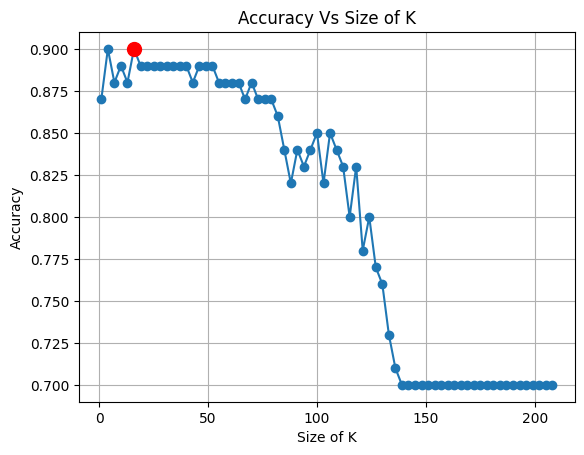

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.9 is achieved for k = 16


In [38]:
# Plot for Accuracy Vs Size of K
acc = []
for i in k_set:
    acc.append(accuracy[i])
highlight_x = max(accuracy, key=accuracy.get)
highlight_y = max(accuracy.values())
plt.plot(k_set, acc, marker='o')
plt.plot(highlight_x, highlight_y, 'ro', markersize=10, label=f'Custom Point ({highlight_x:.2f}, {highlight_y:.2f})')
plt.grid(True)
plt.title('Accuracy Vs Size of K')
plt.xlabel('Size of K')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {highlight_y} is achieved for k = {highlight_x}')

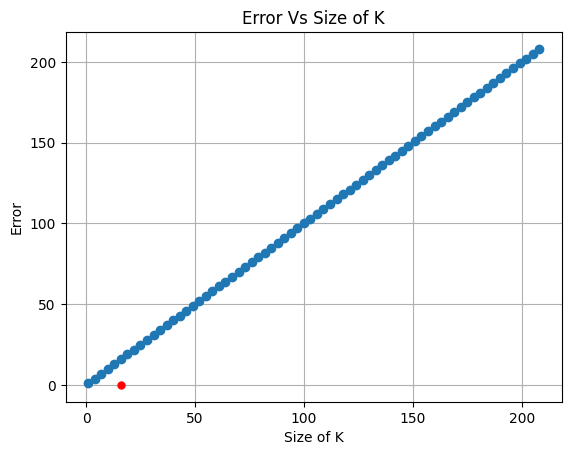

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.09999999999999998 is achieved for k = 16


In [39]:
# Plot for Error Rate (1 - Accuracy) Vs Size of K
err = {}
err_ = []
for i in k_set:
    err[i] = 1 - accuracy[i]
    err_.append(i)
min_x = min(err, key=err.get)
min_y = min(err.values())
plt.plot(k_set, err_, marker='o')
plt.plot(min_x, min_y, 'ro', markersize=5, label=f'Custom Point ({min_x:.2f}, {min_y:.2f})')
plt.grid(True)
plt.title('Error Vs Size of K')
plt.xlabel('Size of K')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {min_y} is achieved for k = {min_x}')

#### Okay So we have found out that the most suitable value of k in this case is k = 16

##### Confusion Matrix for k = 16

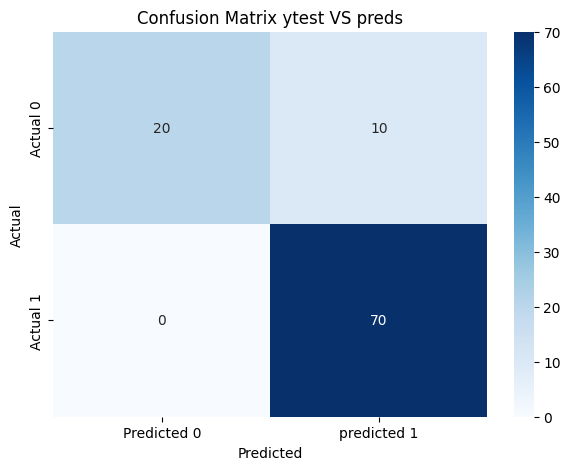

In [40]:
df_16 = pd.DataFrame(cnf[16], index=['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'predicted 1'])

plt.figure(figsize=(7, 5))
sns.heatmap(df_16, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix ytest VS preds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Some other metrics to look at as well

In [41]:
print(f'True Positive Rate for k = 16 is: {recall[16]}')
print(f'True Negative Rate for k = 16 is: {tnr[16]}')
print(f'Precision for k = 16 is: {precision[16]}')
print(f'F1 Score for k = 16 is: {f1[16]}')

True Positive Rate for k = 16 is: 1.0
True Negative Rate for k = 16 is: 0.6666666666666666
Precision for k = 16 is: 0.875
F1 Score for k = 16 is: 0.9333333333333333


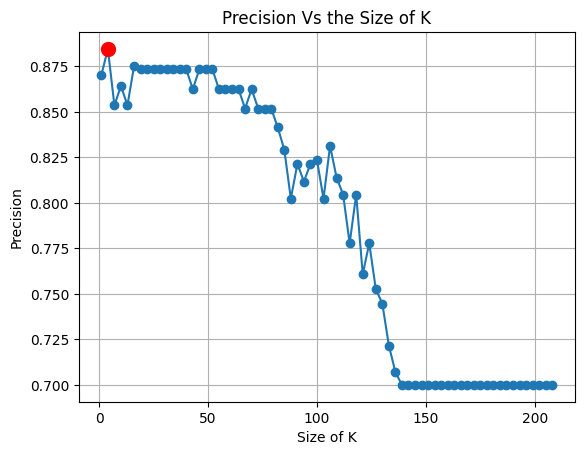

<Figure size 700x500 with 0 Axes>

Highest Precision (for class (Normal)) of 0.8846153846153846 is achieved for k = 4


In [42]:
# Precision for Classifying as 'Normal' Vs the Size of K
precision_ = []
for i in k_set:
    precision_.append(precision[i])
    
high_x = max(precision, key=precision.get)
high_y = max(precision.values())
plt.plot(k_set, precision_, marker='o')
plt.plot(high_x, high_y, 'ro', markersize=10, label=f'Custom Point ({high_x:.2f}, {high_y:.2f})')
plt.grid(True)
plt.title('Precision Vs the Size of K')
plt.xlabel('Size of K')
plt.ylabel('Precision')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Precision (for class (Normal)) of {high_y} is achieved for k = {high_x}')

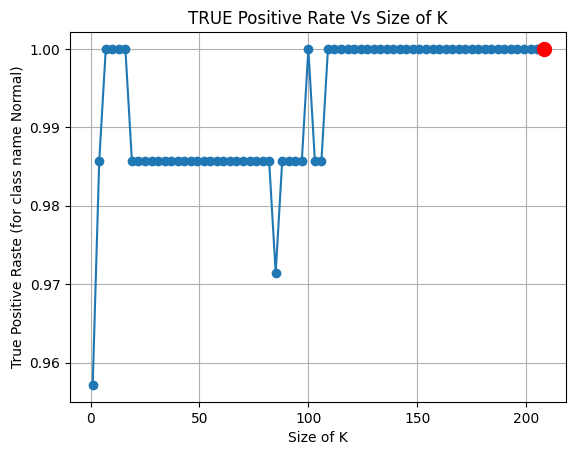

<Figure size 700x500 with 0 Axes>

Highest True Positive Rate of 1.0 is achieved for k = 208


In [43]:
# TRUE Positive Rate Vs Size of K
tpr_ = []
for i in k_set:
    tpr_.append(recall[i])
    
high_x_ = max(recall, key=recall.get)
high_y_ = max(recall.values())
plt.plot(k_set, tpr_, marker='o')
plt.plot(high_x_, high_y_, 'ro', markersize=10, label=f'Custom Point ({high_x_:.2f}, {high_y_:.2f})')
plt.grid(True)
plt.title('TRUE Positive Rate Vs Size of K')
plt.xlabel('Size of K')
plt.ylabel('True Positive Raste (for class name Normal)')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest True Positive Rate of {high_y_} is achieved for k = {high_x_}')

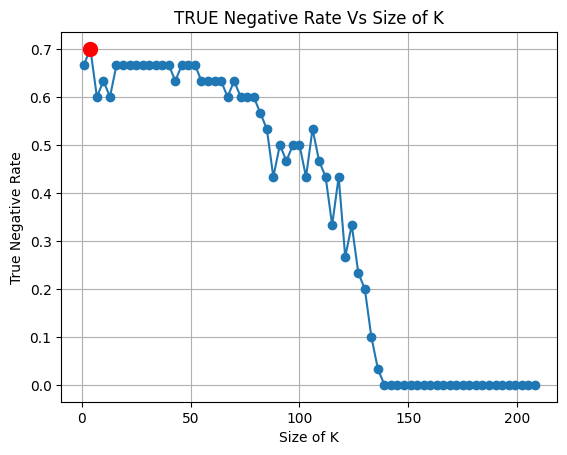

<Figure size 700x500 with 0 Axes>

Highest True Negative Rate of 0.7 is achieved for k = 4


In [44]:
# TRUE Negative Rate (For class Normal) Vs Size of K
tnr_ = []
for i in k_set:
    tnr_.append(tnr[i])
    
_x_ = max(tnr, key=tnr.get)
_y_ = max(tnr.values())
plt.plot(k_set, tnr_, marker='o')
plt.plot(_x_, _y_, 'ro', markersize=10, label=f'Custom Point ({high_x_:.2f}, {high_y_:.2f})')
plt.grid(True)
plt.title('TRUE Negative Rate Vs Size of K')
plt.xlabel('Size of K')
plt.ylabel('True Negative Rate')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest True Negative Rate of {_y_} is achieved for k = {_x_}')

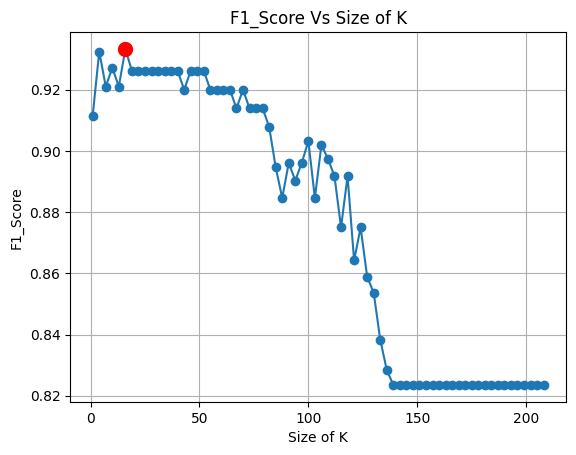

<Figure size 700x500 with 0 Axes>

Highest F1_Score (for class (Normal)) of 0.9333333333333333 is achieved for k = 16


In [45]:
# F1_Score (For class Normal) Vs Size of K
f1_ = []
for i in k_set:
    f1_.append(f1[i])
    
high_x_f1 = max(f1, key=f1.get)
high_y_f1 = max(f1.values())
plt.plot(k_set, f1_, marker='o')
plt.plot(high_x_f1, high_y_f1, 'ro', markersize=10, label=f'Custom Point ({high_x_:.2f}, {high_y_:.2f})')
plt.grid(True)
plt.title('F1_Score Vs Size of K')
plt.xlabel('Size of K')
plt.ylabel('F1_Score')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest F1_Score (for class (Normal)) of {high_y_f1} is achieved for k = {high_x_f1}')

### Q1 C iii)

In [46]:
data_set = []
n = 10
while n <= 210:
    data_set.append(n)
    n += 10    

In [47]:
# new k_set, starting from k = 1,...., 196 (common diff = 5)
new_k_set = []
n = 1
while n <= 196:
    new_k_set.append(n)
    n += 5

In [48]:
df_train['class'].value_counts()

class
1    140
0     70
Name: count, dtype: int64

##### i in data_set and j in k_set
##### So I will be using the K_set from the previous questions which is basically k =[208,...., 4]
##### I will store the results in a dictionary of type [i][j], so that every combination is captured

In [49]:
new_results = {}
df0_all = df_train[df_train['class'] == 0]
df1_all = df_train[df_train['class'] == 1]

In [50]:
# main function for Q1 (c) (iii)
for i in data_set:
    new_results[i] = {}
    a = round(i/3)
    b = round((2/3)*i)
    df0 = df0_all.iloc[:a, :]
    df1 = df1_all.iloc[:b, :]
    df_new = pd.concat([df0, df1])
    dfx_new = df_new.drop(columns='class').to_numpy(dtype=float)
    dfy_new = df_new['class'].values
    for j in new_k_set:
        mod = KNN(k = j)
        mod.fit(dfx_new, dfy_new)
        new_results[i][j] = mod.predict(X_test)

In [51]:
# Lets Plot the error curve this time we will learn the effect of size of traning data on learning
# Okay so first lets start by anlyzing the accuracy for a set of size i and size of k as j
# Calculation of Accuracy
accuracy_new = {}
try:
    for i in data_set:
        accuracy_new[i] = {}
        for j in new_k_set:
            accuracy_new[i][j] = accuracy_score(y_test, new_results[i][j])
except Exception as e:
    print(f'Error in Calculation of Accuracy: {e}')

In [52]:
accuracy_new[210][196]

0.7

In [53]:
# Now lets Calculate the error before moving to plotting the graphs
error_new = {}
try:
    for i in data_set:
        error_new[i] = {}
        for j in new_k_set:
            a = np.float64(accuracy_new[i][j])
            error_new[i][j] = (1.0 - a)
except Exception as err:
    print(f"Error in calculating error: {err}")

In [54]:
error_new[210][196]

np.float64(0.30000000000000004)

In [55]:
# Heatmap plot for accuracy considering the two important factors 
# size of data_set (i) and size of k (j)
accu_df = []
for i, j_dict in accuracy_new.items():
    for j, accu in j_dict.items():
        accu_df.append({ 'DataSize': i, 'KSize': j, 'Accuracy': accu })
accu_df = pd.DataFrame(accu_df)

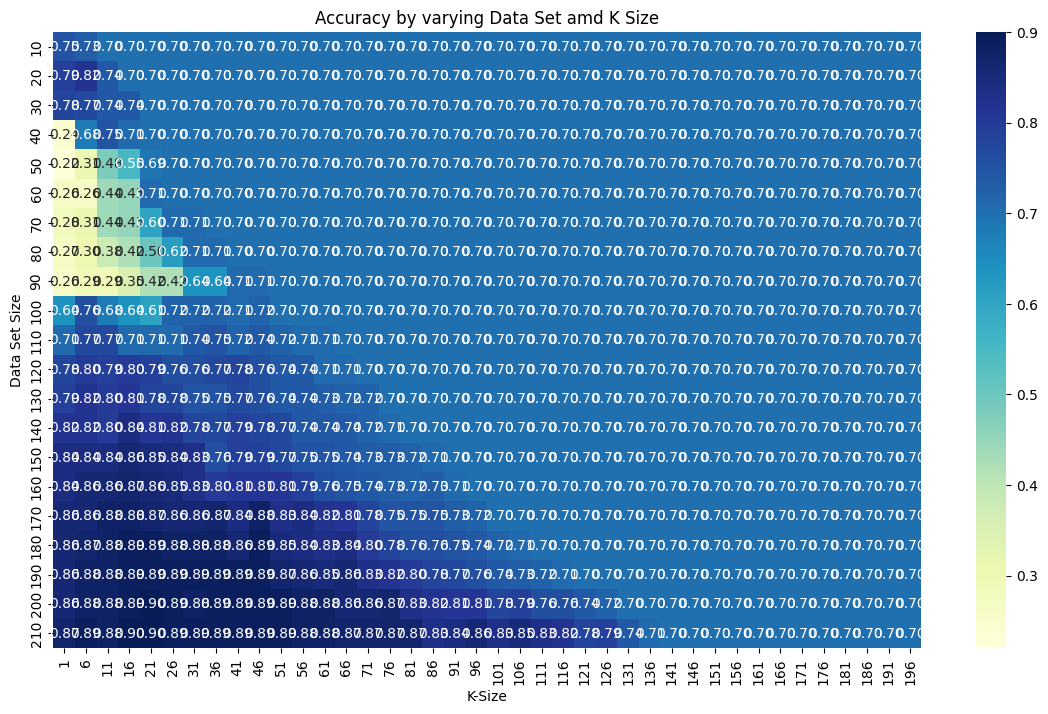

In [56]:
accu_df_ = accu_df.pivot(index="DataSize", columns="KSize", values="Accuracy")

plt.figure(figsize=(14, 8))
sns.heatmap(accu_df_, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Accuracy by varying Data Set amd K Size")
plt.xlabel("K-Size")
plt.ylabel("Data Set Size")
plt.show()

In [57]:
# Heatmap plot for error considering the two important factors
# size of data_set (i) and size of k (j)
err_df = []
for i, j_dict in error_new.items():
    for j, err in j_dict.items():
        err_df.append({ 'DataSize': i, 'KSize': j, 'Error': err })
err_df = pd.DataFrame(err_df)

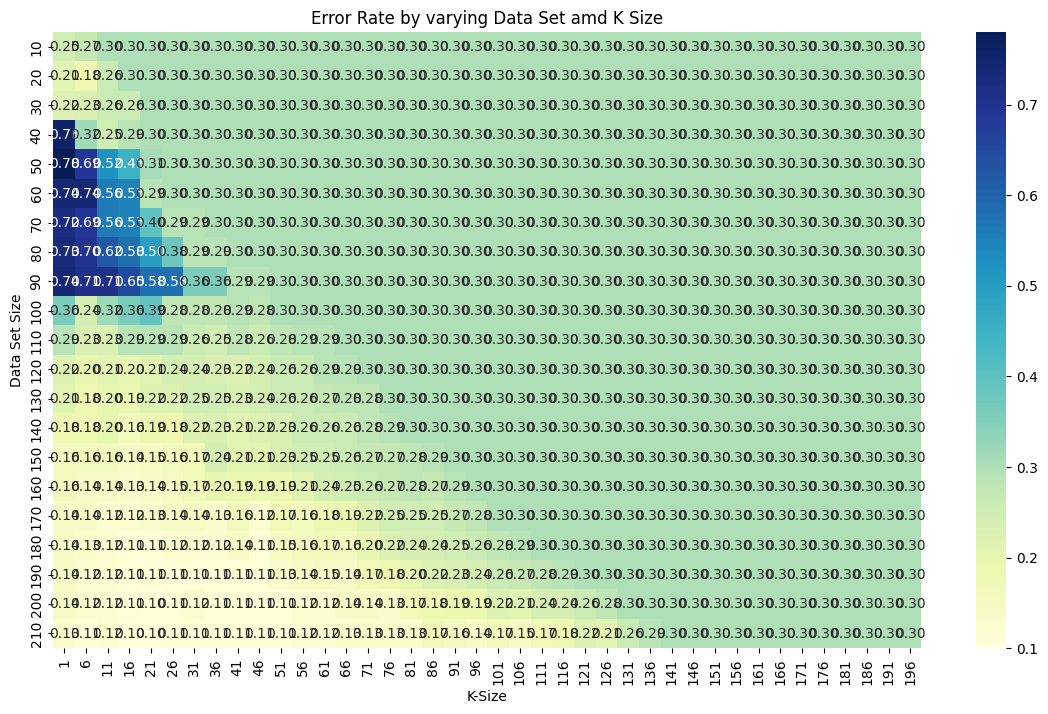

In [58]:
err_df_ = err_df.pivot(index="DataSize", columns="KSize", values="Error")

plt.figure(figsize=(14, 8))
sns.heatmap(err_df_, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Error Rate by varying Data Set amd K Size")
plt.xlabel("K-Size")
plt.ylabel("Data Set Size")
plt.show()

### Q1.(d)(i)

In [59]:
# Minkowski Distance Calculations
def p_root(value, root):
    root_value = 1 / float(root)
    return round(Decimal(value) ** Decimal(root_value), 3)
    
def minkowski_dist(x, y, p):
    return p_root(sum(pow(abs(a - b), p) for a, b in zip(x, y)), p)

In [60]:
# Custom KNN class
class MinkowKNN:
    def __init__(self, k=3, p=1):
        self.k = k
        self.p = p
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        dists = [minkowski_dist(x, x_train, self.p) for x_train in self.X_train]

        k_indices = np.argsort(dists)[:self.k]
        k_n_labels = [self.y_train[i] for i in k_indices]

        most_comm = Counter(k_n_labels).most_common()
        return most_comm[0][0]

### Q1.(d)(i) A. For p = 1, Manhattan Distance 

In [61]:
#  Using X_train, X_test, y_train, y_test and new_k_set 
minkow_res = {}
try:
    for i in new_k_set:
        mod_ = MinkowKNN(k = i)
        mod_.fit(X_train, y_train)
        minkow_res[i] = mod_.predict(X_test)
except Exception as e:
    print(f'Error testing the model on the minkow function: {e}')

In [62]:
# Calculation of Accuracy & Error
minkow_accuracy = {}
minkow_err = {}
try:
    for i in new_k_set:
        a = accuracy_score(y_test, minkow_res[i])
        minkow_accuracy[i] = a
        minkow_err[i] = (1.0 - a)
except Exception as e2:
    print(f'Error in Calculating metrics: {e2}')

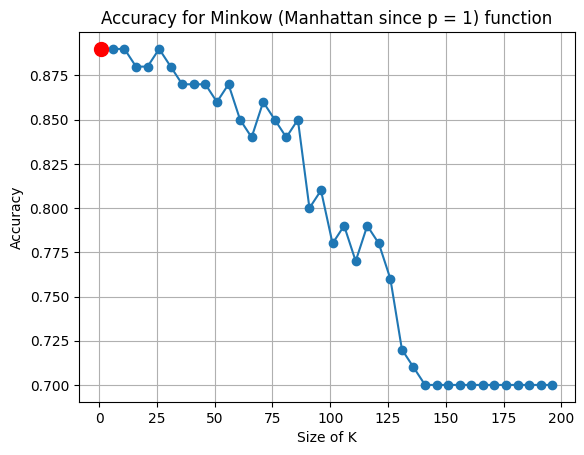

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.89 is achieved for k = 1


In [63]:
# Plot for Accuracy using Minkow and new_k_set
minkow_acc = []
for i in new_k_set:
    minkow_acc.append(minkow_accuracy[i])
highlight_x_minkow = max(minkow_accuracy, key=minkow_accuracy.get)
highlight_y_minkow = max(minkow_accuracy.values())
plt.plot(new_k_set, minkow_acc, marker='o')
plt.plot(highlight_x_minkow, highlight_y_minkow, 'ro', markersize=10, label=f'Custom Point ({highlight_x_minkow:.2f}, {highlight_y_minkow:.2f})')
plt.grid(True)
plt.title('Accuracy for Minkow (Manhattan since p = 1) function')
plt.xlabel('Size of K')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {highlight_y_minkow} is achieved for k = {highlight_x_minkow}')

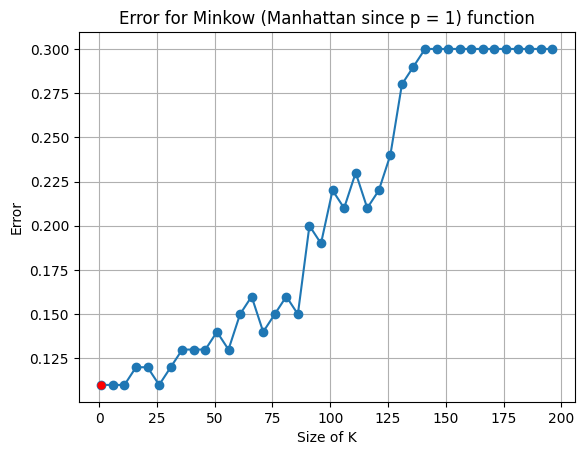

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.10999999999999999 is achieved for k = 1


In [64]:
# Plot for Error Rate (1 - Accuracy) for p = 1 Manhattan distance function and new_k_set
min_err = []
for i in new_k_set:
    min_err.append(minkow_err[i])
min_x_min = min(minkow_err, key=minkow_err.get)
min_y_min = min(minkow_err.values())
plt.plot(new_k_set, min_err, marker='o')
plt.plot(min_x_min, min_y_min, 'ro', markersize=5, label=f'Custom Point ({min_x_min:.2f}, {min_y_min:.2f})')
plt.grid(True)
plt.title('Error for Minkow (Manhattan since p = 1) function')
plt.xlabel('Size of K')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {min_y_min} is achieved for k = {min_x_min}')

### Q1.(d)(i) B. with log(p) ∈ {0.1, 0.2, 0.3, . . . , 1}

In [65]:
# Constructing new series of p_values
log_vals = np.linspace(0.1, 1.0, 10)
p_values = 10 ** log_vals
p_values

array([ 1.25892541,  1.58489319,  1.99526231,  2.51188643,  3.16227766,
        3.98107171,  5.01187234,  6.30957344,  7.94328235, 10.        ])

##### I will be using k = 1 for which I found the highest accuracy using manhattan distance

In [66]:
newp_res = {}
try:
    for i in p_values:
        model = MinkowKNN(k=1, p = i)
        model.fit(X_train, y_train)
        newp_res[i] = model.predict(X_test)
except Exception as e3:
    print(f"Error training newp values model: {e3}")

In [67]:
# Calculation of Accuracy & Error
newp_accuracy = {}
newp_err = {}
try:
    for i in p_values:
        a = accuracy_score(y_test, newp_res[i])
        newp_accuracy[i] = a
        newp_err[i] = (1.0 - a)
except Exception as e2:
    print(f'Error in Calculating metrics: {e2}')

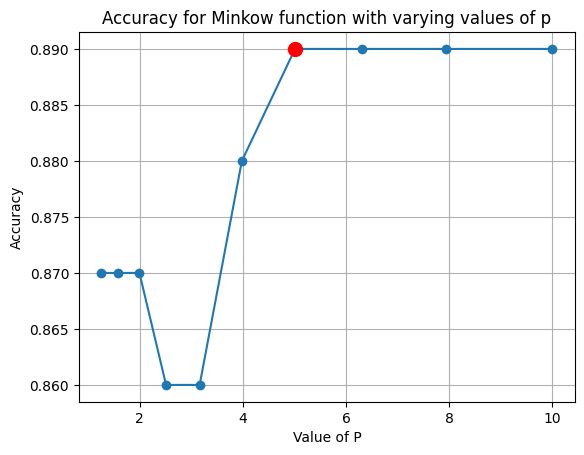

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.89 is achieved for p value of = 5.011872336272724


In [68]:
# Plot for Accuracy using Minkow and the new p values
newp_minkow_acc = []
for i in p_values:
    newp_minkow_acc.append(newp_accuracy[i])
newp_x_minkow = max(newp_accuracy, key=newp_accuracy.get)
newp_y_minkow = max(newp_accuracy.values())
plt.plot(p_values, newp_minkow_acc, marker='o')
plt.plot(newp_x_minkow, newp_y_minkow, 'ro', markersize=10, label=f'Custom Point ({newp_x_minkow:.2f}, {newp_y_minkow:.2f})')
plt.grid(True)
plt.title('Accuracy for Minkow function with varying values of p')
plt.xlabel('Value of P')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {newp_y_minkow} is achieved for p value of = {newp_x_minkow}')

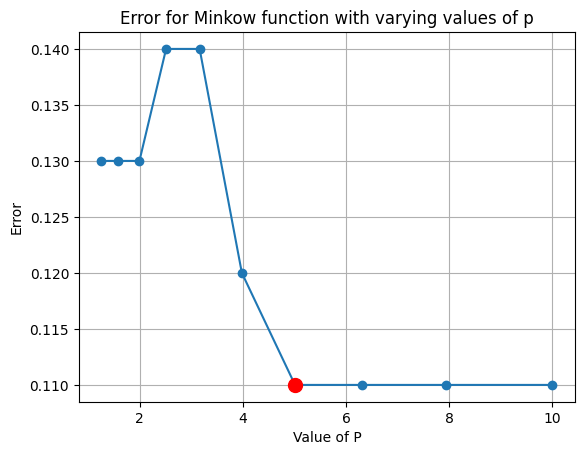

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.10999999999999999 is achieved for p value of = 5.011872336272724


In [70]:
# Plot for Error using Minkow function and the new p values
newp_minkow_err = []
for i in p_values:
    newp_minkow_err.append(newp_err[i])
newp_x_min = min(newp_err, key=newp_err.get)
newp_y_min = min(newp_err.values())
plt.plot(p_values, newp_minkow_err, marker='o')
plt.plot(newp_x_min, newp_y_min, 'ro', markersize=10, label=f'Custom Point ({newp_x_min:.2f}, {newp_y_min:.2f})')
plt.grid(True)
plt.title('Error for Minkow function with varying values of p')
plt.xlabel('Value of P')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {newp_y_min} is achieved for p value of = {newp_x_min}')

### Q1.(D)(i)C.

In [72]:
# Function to Calculate Chebyshev distance
def chebyshev_dist(x1, x2):
    return np.max(np.abs(x1 - x2))
    
# Custom KNN class
class ChebyShevKNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        dists = [chebyshev_dist(x, x_train) for x_train in self.X_train]

        k_indices = np.argsort(dists)[:self.k]
        k_n_labels = [self.y_train[i] for i in k_indices]

        most_comm = Counter(k_n_labels).most_common()
        return most_comm[0][0]

In [73]:
# Now train the model using the chebyshev dist function and new_k_set, X_train, y_train
cheby_res = {}
try:
    for i in new_k_set:
        model = ChebyShevKNN(k = i)
        model.fit(X_train, y_train)
        cheby_res[i] = model.predict(X_test)
except Exception as e4:
    print(f'An error occured in traing the chebyshev dist based KNN: {e4}')

In [75]:
# Calculation of Accuracy & Error
cheb_accuracy = {}
cheb_err = {}
try:
    for i in new_k_set:
        a = accuracy_score(y_test, cheby_res[i])
        cheb_accuracy[i] = a
        cheb_err[i] = (1.0 - a)
except Exception as e5:
    print(f'Error in Calculating metrics: {e5}')

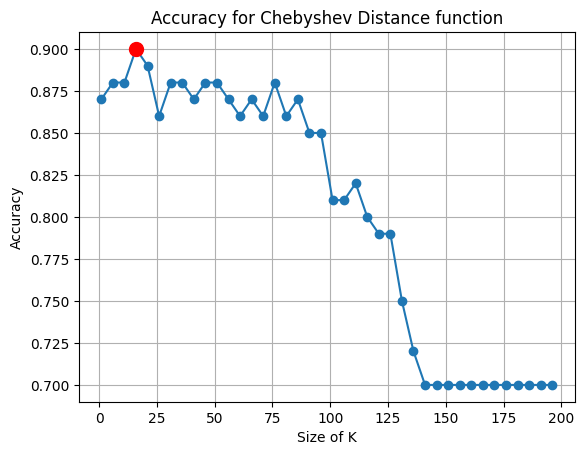

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.9 is achieved for k = 16


In [78]:
# Plot for Accuracy using ChebyShev Distance
cheby_acc = []
for i in new_k_set:
    cheby_acc.append(cheb_accuracy[i])
highlight_x_cheby = max(cheb_accuracy, key=cheb_accuracy.get)
highlight_y_cheby = max(cheb_accuracy.values())
plt.plot(new_k_set, cheby_acc, marker='o')
plt.plot(highlight_x_cheby, highlight_y_cheby, 'ro', markersize=10, label=f'Custom Point ({highlight_x_cheby:.2f}, {highlight_y_cheby:.2f})')
plt.grid(True)
plt.title('Accuracy for Chebyshev Distance function')
plt.xlabel('Size of K')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {highlight_y_cheby} is achieved for k = {highlight_x_cheby}')

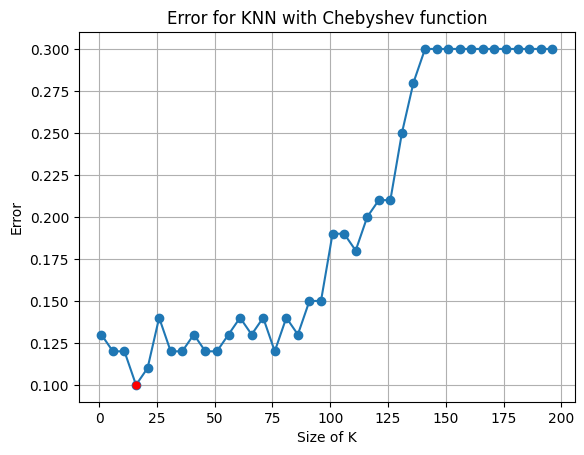

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.09999999999999998 is achieved for k = 16


In [105]:
# Plot for Error Rate (1 - Accuracy) for p = 1 Chebyshev distance function
cheby_err = []
for i in new_k_set:
    cheby_err.append(cheb_err[i])
cheb_x_min = min(cheb_err, key=cheb_err.get)
cheb_y_min = min(cheb_err.values())
plt.plot(new_k_set, cheby_err, marker='o')
plt.plot(cheb_x_min, cheb_y_min, 'ro', markersize=5, label=f'Custom Point ({cheb_x_min:.2f}, {cheb_y_min:.2f})')
plt.grid(True)
plt.title('Error for KNN with Chebyshev function')
plt.xlabel('Size of K')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {cheb_y_min} is achieved for k = {cheb_x_min}')

In [83]:
# KNN with the Mahalanobis distance metric
mknn_res = {}
try:
    cov_mtr = np.cov(X_train, rowvar=False)
    for i in new_k_set:
        model = KNeighborsClassifier(
            n_neighbors=i,
            metric='mahalanobis',
            metric_params={'VI': cov_mtr}
        )
        model.fit(X_train, y_train)
        mknn_res[i] = model.predict(X_test)
except Exception as e6:
    print(f'Error ion training the model on mahalanobis metric: {e6}')

In [89]:
# Calculation of Accuracy & Error
mknn_accuracy = {}
mknn_err = {}
try:
    for i in new_k_set:
        a = accuracy_score(y_test, mknn_res[i])
        mknn_accuracy[i] = a
        mknn_err[i] = (1.0 - a)
except Exception as e7:
    print(f'Error in Calculating metrics: {e7}')

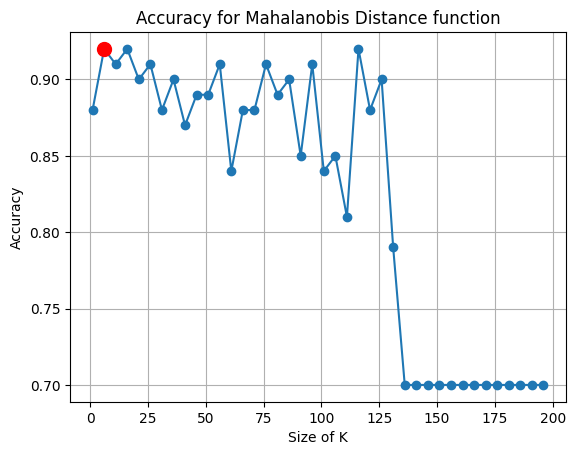

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.92 is achieved for k = 6


In [91]:
# Plot for Accuracy using Mahalanobis Distance
mknn_acc = []
for i in new_k_set:
    mknn_acc.append(mknn_accuracy[i])
highlight_x_mknn = max(mknn_accuracy, key=mknn_accuracy.get)
highlight_y_mknn = max(mknn_accuracy.values())
plt.plot(new_k_set, mknn_acc, marker='o')
plt.plot(highlight_x_mknn, highlight_y_mknn, 'ro', markersize=10, label=f'Custom Point ({highlight_x_mknn:.2f}, {highlight_y_mknn:.2f})')
plt.grid(True)
plt.title('Accuracy for Mahalanobis Distance function')
plt.xlabel('Size of K')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {highlight_y_mknn} is achieved for k = {highlight_x_mknn}')

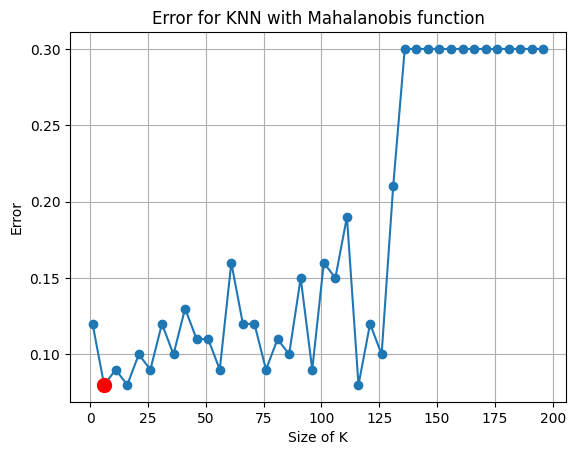

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.07999999999999996 is achieved for k = 6


In [93]:
# Plot for Error Rate for Mahalanobis distance function
mknn_err_ = []
for i in new_k_set:
    mknn_err_.append(mknn_err[i])
mknn_x_min = min(mknn_err, key=mknn_err.get)
mknn_y_min = min(mknn_err.values())
plt.plot(new_k_set, mknn_err_, marker='o')
plt.plot(mknn_x_min, mknn_y_min, 'ro', markersize=10, label=f'Custom Point ({mknn_x_min:.2f}, {mknn_y_min:.2f})')
plt.grid(True)
plt.title('Error for KNN with Mahalanobis function')
plt.xlabel('Size of K')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {mknn_y_min} is achieved for k = {mknn_x_min}')

### Q1. (E)

In [103]:
# Custom Weighted KNN class
class WeightedKNN:
    def __init__(self, k=3, metric='Euclidean'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        if self.metric == 'Euclidean':
            dists = [euclidean_dist(x, x_train) for x_train in self.X_train]
            
        elif self.metric == 'Manhattan':
            dists = [minkowski_dist(x, x_train, 1) for x_train in self.X_train]
        
        elif self.metric == 'Chebyshev':
            dists = [chebyshev_dist(x, x_train) for x_train in self.X_train]

        k_indices = np.argsort(dists)[:self.k]

        k_dists = np.array([dists[i] for i in k_indices], dtype=float)
        weights = 1 / (k_dists + 1e-5)

        class_scores = {}
        for i, idx in enumerate(k_indices):
            label = self.y_train[idx]
            class_scores[label] = class_scores.get(label, 0) + weights[i]
        
        return max(class_scores, key=class_scores.get)

#### Now we run the Weighted KNN class updated as above for:
#### 1. Euclidean
#### 2. Manhattan and
#### 3. Chebyshev distances

In [104]:
# I will use the new_k_set from previous subquestions
weighted_res = {}
man_weighted_res = {}
cheby_weighted_res = {}
try:
    print('Distance function 1: Eucliodean with Weighted')
    print('Starting...')
    for i in new_k_set:
        a = WeightedKNN(k=i, metric='Euclidean')
        a.fit(X_train, y_train)
        weighted_res[i] = a.predict(X_test)
    print('Success!')

    print('Distance function 2: Manhattan with Weighted')
    print('Starting...')
    for j in new_k_set:
        b = WeightedKNN(k=j, metric='Manhattan')
        b.fit(X_train, y_train)
        man_weighted_res[j] = b.predict(X_test)
    print('Success!')
    
    print('Distance function 3: Chebyshev with Weighted')
    print('Starting...')
    for l in new_k_set:
        c = WeightedKNN(k=l, metric='Chebyshev')
        c.fit(X_train, y_train)
        cheby_weighted_res[l] = c.predict(X_test)
    print('Success!')
    
except Exception as e8:
    print(f'Error running the weighted KNN class: {e8}')

Distance function 1: Eucliodean with Weighted
Starting...
Success!
Distance function 2: Manhattan with Weighted
Starting...
Success!
Distance function 3: Chebyshev with Weighted
Starting...
Success!


In [106]:
# Calculation of Accuracy & Error
weighted_accuracy = {}
man_weighted_accuracy = {}
cheb_weighted_accuracy = {}
weighted_err = {}
man_weighted_err = {}
cheb_weighted_err = {}
try:
    for i in new_k_set:
        a = accuracy_score(y_test, weighted_res[i])
        b = accuracy_score(y_test, man_weighted_res[i])
        c = accuracy_score(y_test, cheby_weighted_res[i])
        weighted_accuracy[i] = a
        man_weighted_accuracy[i] = b
        cheb_weighted_accuracy[i] = c
        weighted_err[i] = (1.0 - a)
        man_weighted_err[i] = (1.0 - b)
        cheb_weighted_err[i] = (1.0 - c)
except Exception as e5:
    print(f'Error in Calculating metrics: {e5}')

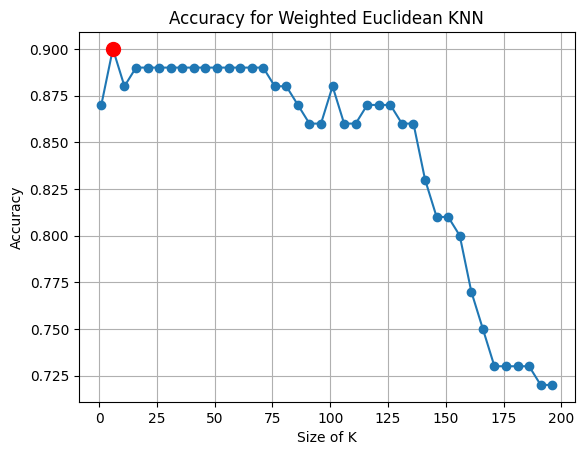

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.9 is achieved for k = 6


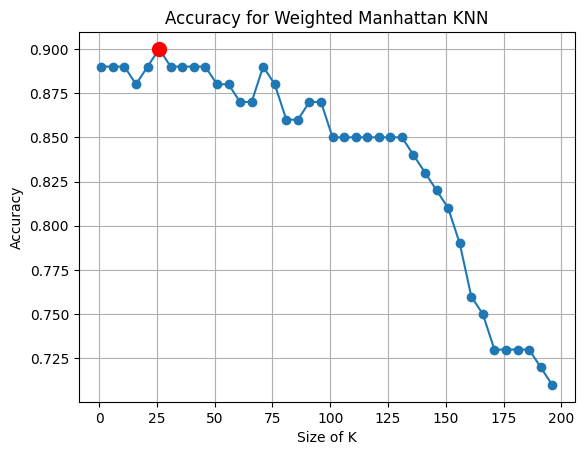

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.9 is achieved for k = 26


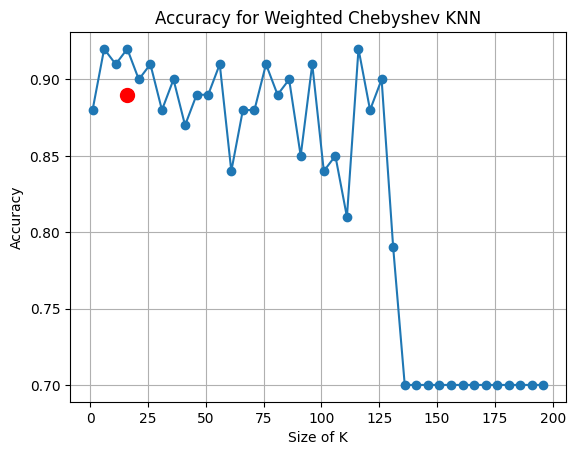

<Figure size 700x500 with 0 Axes>

Highest Accuracy of 0.89 is achieved for k = 16


In [107]:
# Plot for Accuracy for weighted Euclidean
weighted_acc = []
for i in new_k_set:
    weighted_acc.append(weighted_accuracy[i])
highlight_x_weighted_accuracy = max(weighted_accuracy, key=weighted_accuracy.get)
highlight_y_weighted_accuracy = max(weighted_accuracy.values())
plt.plot(new_k_set, weighted_acc, marker='o')
plt.plot(highlight_x_weighted_accuracy, highlight_y_weighted_accuracy, 'ro', markersize=10, label=f'Custom Point ({highlight_x_weighted_accuracy:.2f}, {highlight_y_weighted_accuracy:.2f})')
plt.grid(True)
plt.title('Accuracy for Weighted Euclidean KNN')
plt.xlabel('Size of K')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {highlight_y_weighted_accuracy} is achieved for k = {highlight_x_weighted_accuracy}')

# Plot for Accuracy for Weighted Manhattan
man_weighted_acc = []
for i in new_k_set:
    man_weighted_acc.append(man_weighted_accuracy[i])
highlight_x_man_weighted_accuracy = max(man_weighted_accuracy, key=man_weighted_accuracy.get)
highlight_y_man_weighted_accuracy = max(man_weighted_accuracy.values())
plt.plot(new_k_set, man_weighted_acc, marker='o')
plt.plot(highlight_x_man_weighted_accuracy, highlight_y_man_weighted_accuracy, 'ro', markersize=10, label=f'Custom Point ({highlight_x_man_weighted_accuracy:.2f}, {highlight_y_man_weighted_accuracy:.2f})')
plt.grid(True)
plt.title('Accuracy for Weighted Manhattan KNN')
plt.xlabel('Size of K')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {highlight_y_man_weighted_accuracy} is achieved for k = {highlight_x_man_weighted_accuracy}')

# Plot for Accuracy for Weighted Chebyshev
cheb_weighted_acc = []
for i in new_k_set:
    cheb_weighted_acc.append(cheb_weighted_accuracy[i])
highlight_x_cheb_weighted_accuracy = max(cheb_weighted_accuracy, key=cheb_weighted_accuracy.get)
highlight_y_cheb_weighted_accuracy = max(cheb_weighted_accuracy.values())
plt.plot(new_k_set, mknn_acc, marker='o')
plt.plot(highlight_x_cheb_weighted_accuracy, highlight_y_cheb_weighted_accuracy, 'ro', markersize=10, label=f'Custom Point ({highlight_x_cheb_weighted_accuracy:.2f}, {highlight_y_cheb_weighted_accuracy:.2f})')
plt.grid(True)
plt.title('Accuracy for Weighted Chebyshev KNN')
plt.xlabel('Size of K')
plt.ylabel('Accuracy')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Highest Accuracy of {highlight_y_cheb_weighted_accuracy} is achieved for k = {highlight_x_cheb_weighted_accuracy}')

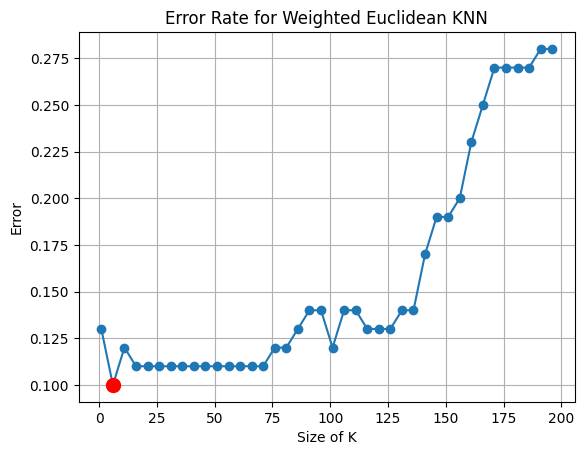

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.09999999999999998 is achieved for k = 6


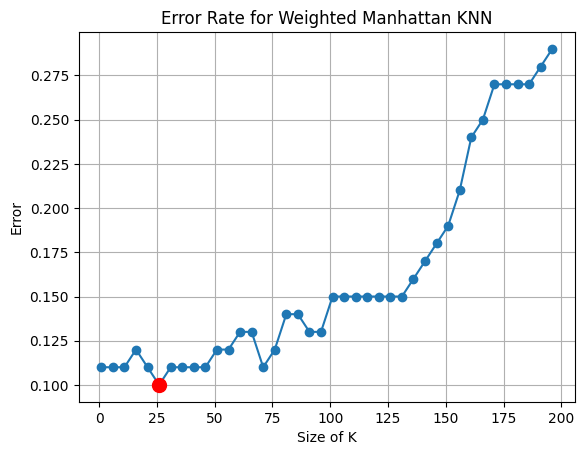

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.09999999999999998 is achieved for k = 26


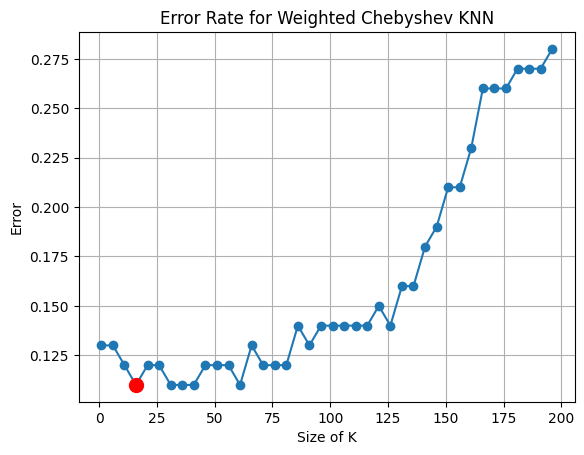

<Figure size 700x500 with 0 Axes>

Lowest Error of 0.10999999999999999 is achieved for k = 16


In [109]:
# Plot for Error Rate for Weighted Euclidean KNN
weighted_err_ = []
for i in new_k_set:
    weighted_err_.append(weighted_err[i])
_x_weighted_err = min(weighted_err, key=weighted_err.get)
_y_weighted_err = min(weighted_err.values())
plt.plot(new_k_set, weighted_err_, marker='o')
plt.plot(_x_weighted_err, _y_weighted_err, 'ro', markersize=10, label=f'Custom Point ({_x_weighted_err:.2f}, {_y_weighted_err:.2f})')
plt.grid(True)
plt.title('Error Rate for Weighted Euclidean KNN')
plt.xlabel('Size of K')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {_y_weighted_err} is achieved for k = {_x_weighted_err}')

# Plot for Error Rate for Weighted Manhattan KNN
man_weighted_err_ = []
for i in new_k_set:
    man_weighted_err_.append(man_weighted_err[i])
_x_man_weighted_err = min(man_weighted_err, key=man_weighted_err.get)
_y_man_weighted_err = min(man_weighted_err.values())
plt.plot(new_k_set, man_weighted_err_, marker='o')
plt.plot(_x_man_weighted_err, _y_man_weighted_err, 'ro', markersize=10, label=f'Custom Point ({_x_man_weighted_err:.2f}, {_y_man_weighted_err:.2f})')
plt.grid(True)
plt.title('Error Rate for Weighted Manhattan KNN')
plt.xlabel('Size of K')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {_y_man_weighted_err} is achieved for k = {_x_man_weighted_err}')

# Plot for Error Rate for Weighted Chebyshev KNN
weighted_cheby_err_ = []
for i in new_k_set:
    weighted_cheby_err_.append(cheb_weighted_err[i])
_x_cheb_weighted_err = min(cheb_weighted_err, key=cheb_weighted_err.get)
_y_cheb_weighted_err = min(cheb_weighted_err.values())
plt.plot(new_k_set, weighted_cheby_err_, marker='o')
plt.plot(_x_cheb_weighted_err, _y_cheb_weighted_err, 'ro', markersize=10, label=f'Custom Point ({_x_cheb_weighted_err:.2f}, {_y_cheb_weighted_err:.2f})')
plt.grid(True)
plt.title('Error Rate for Weighted Chebyshev KNN')
plt.xlabel('Size of K')
plt.ylabel('Error')
plt.figure(figsize=(7, 5))
plt.show()
print(f'Lowest Error of {_y_cheb_weighted_err} is achieved for k = {_x_cheb_weighted_err}')

#### Lowest Training Error Rate in this homework was observed to be 0.1 for KNN with K = 21

In [112]:
err_df.loc[err_df['Error'].idxmin()]

DataSize    200.0
KSize        21.0
Error         0.1
Name: 764, dtype: float64